In [41]:
print('hello world')

hello world


- WE WILL BUILD AND COMPARE 2 MODELS HERE

Model 1 — SARIMA (Statistical — handles seasonality well)

Model 2 — LSTM (Deep Learning — Neural Network approach)

In [42]:
### GOT TO IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [43]:
### MERGING CV FILES

base_path = r"D:\AI COURSE\Daily_practice\PROJECTS\PRAICP-1004-RainfallTS\Data"

df_total   = pd.read_csv(base_path + r"\rainfall-monthly-total.csv")
df_highest = pd.read_csv(base_path + r"\rainfall-monthly-highest-daily-total.csv")
df_days    = pd.read_csv(base_path + r"\rainfall-monthly-number-of-rain-days.csv")

# Merge all on 'month' column
df = df_total.merge(df_highest, on='month').merge(df_days, on='month')

# Parse month as datetime and set as index
df['month'] = pd.to_datetime(df['month'])
df = df.set_index('month')
df = df.sort_index()

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDate Range:", df.index.min(), "to", df.index.max())
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (462, 3)

Columns: ['total_rainfall', 'maximum_rainfall_in_a_day', 'no_of_rainy_days']

Date Range: 1982-01-01 00:00:00 to 2020-06-01 00:00:00

First 5 rows:
            total_rainfall  maximum_rainfall_in_a_day  no_of_rainy_days
month                                                                  
1982-01-01           107.1                       36.5                10
1982-02-01            27.8                        9.4                 5
1982-03-01           160.8                       61.7                11
1982-04-01           157.0                       45.1                14
1982-05-01           102.2                       33.0                10


In [44]:
### STATISTIC AND MISSING VALUES

print("Missing Values")
print(df.isnull().sum())

print("\n Descriptive Statistics")
print(df.describe().round(2))

print("\n=== Key Observations ===")
print(f"Total months of data     : {len(df)}")
print(f"Avg monthly rainfall     : {df['total_rainfall'].mean():.2f} mm")
print(f"Max monthly rainfall     : {df['total_rainfall'].max():.2f} mm in {df['total_rainfall'].idxmax().strftime('%Y-%m')}")
print(f"Min monthly rainfall     : {df['total_rainfall'].min():.2f} mm in {df['total_rainfall'].idxmin().strftime('%Y-%m')}")
print(f"Avg highest daily total  : {df['maximum_rainfall_in_a_day'].mean():.2f} mm")
print(f"Avg rain days per month  : {df['no_of_rainy_days'].mean():.1f} days")

Missing Values
total_rainfall               0
maximum_rainfall_in_a_day    0
no_of_rainy_days             0
dtype: int64

 Descriptive Statistics
       total_rainfall  maximum_rainfall_in_a_day  no_of_rainy_days
count          462.00                     462.00            462.00
mean           176.24                      52.36             13.96
std            113.30                      35.69              4.95
min              0.20                       0.20              1.00
25%             89.02                      30.62             11.00
50%            158.45                      43.45             14.00
75%            237.95                      63.15             18.00
max            765.90                     216.20             27.00

=== Key Observations ===
Total months of data     : 462
Avg monthly rainfall     : 176.24 mm
Max monthly rainfall     : 765.90 mm in 2006-12
Min monthly rainfall     : 0.20 mm in 2014-02
Avg highest daily total  : 52.36 mm
Avg rain days per month  : 

In [45]:
## observations here

- Before modelling, got to understand the data. 
- I've checked for missing values, compute descriptive statistics, and observe key characteristics. 
- This directly informs our preprocessing decisions.

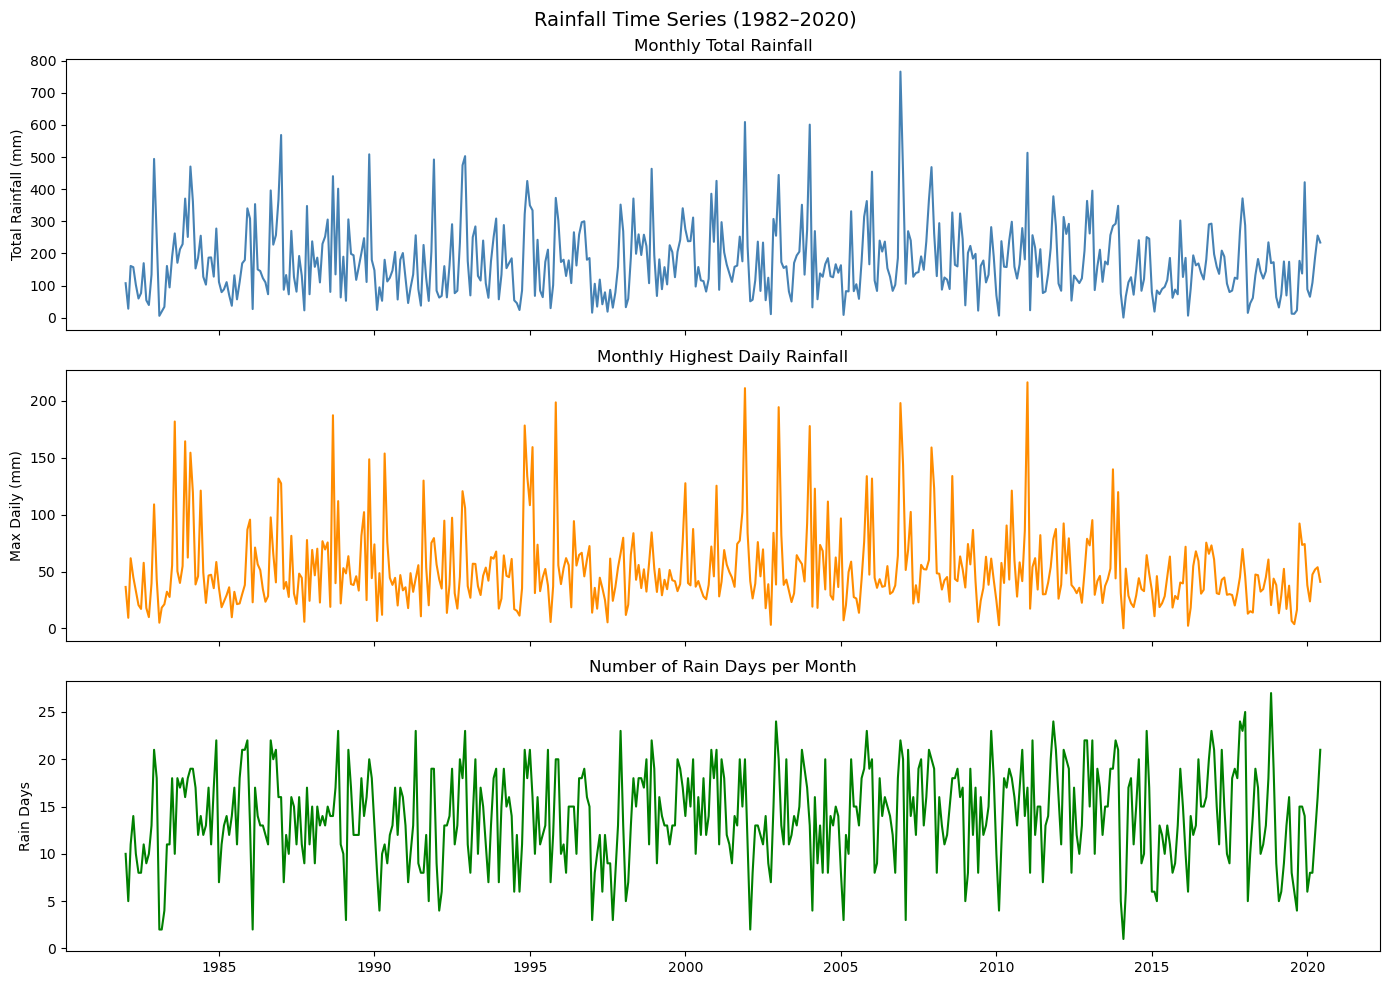

In [46]:
### VISUALIZE RAW TIMESERIES

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Rainfall Time Series (1982–2020)', fontsize=14)

axes[0].plot(df['total_rainfall'], color='steelblue')
axes[0].set_ylabel('Total Rainfall (mm)')
axes[0].set_title('Monthly Total Rainfall')

axes[1].plot(df['maximum_rainfall_in_a_day'], color='darkorange')
axes[1].set_ylabel('Max Daily (mm)')
axes[1].set_title('Monthly Highest Daily Rainfall')

axes[2].plot(df['no_of_rainy_days'], color='green')
axes[2].set_ylabel('Rain Days')
axes[2].set_title('Number of Rain Days per Month')

plt.tight_layout()
plt.show()

In [47]:
### OBSERVATIONS HERE

- Plotting all three variables over time helps us identify trends, seasonality, and anomalies visually. 
- This is a critical first step in any time series project before applying any model.

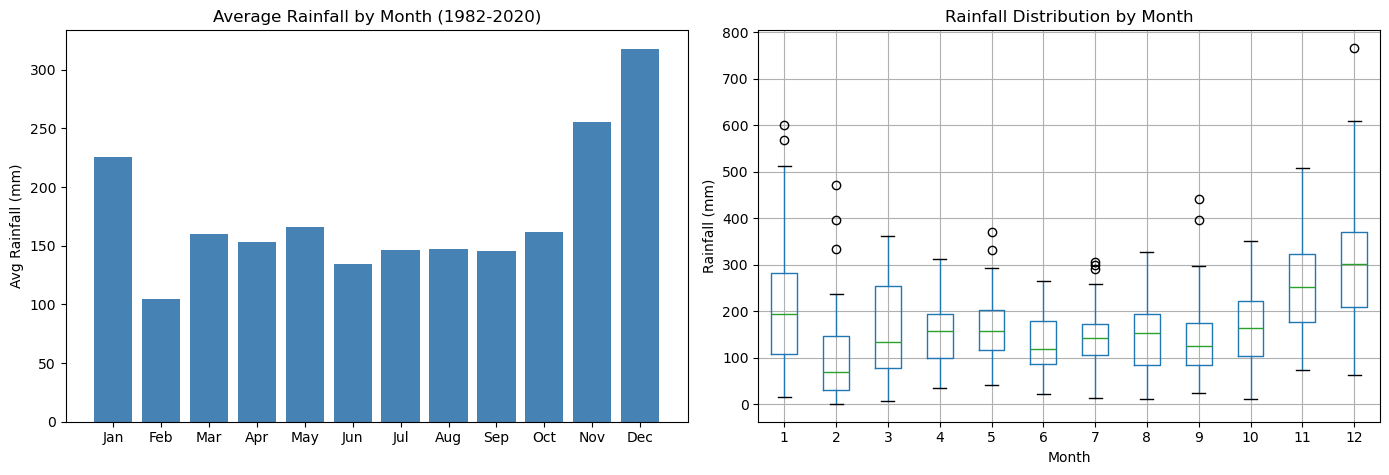

Wettest month on average  : Dec (317.6 mm)
Driest month on average   : Feb (104.7 mm)


In [48]:
### MONTHLY SEASON ANALYSIS

df_monthly = df.copy()
df_monthly['month_num'] = df_monthly.index.month

monthly_avg = df_monthly.groupby('month_num')['total_rainfall'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(month_names, monthly_avg.values, color='steelblue')
axes[0].set_title('Average Rainfall by Month (1982-2020)')
axes[0].set_ylabel('Avg Rainfall (mm)')

# Boxplot to show variability per month
df_monthly['month_name'] = df_monthly.index.strftime('%b')
df_monthly.boxplot(column='total_rainfall', by='month_num', ax=axes[1])
axes[1].set_title('Rainfall Distribution by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Rainfall (mm)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("Wettest month on average  :", month_names[monthly_avg.idxmax()-1], f"({monthly_avg.max():.1f} mm)")
print("Driest month on average   :", month_names[monthly_avg.idxmin()-1], f"({monthly_avg.min():.1f} mm)")

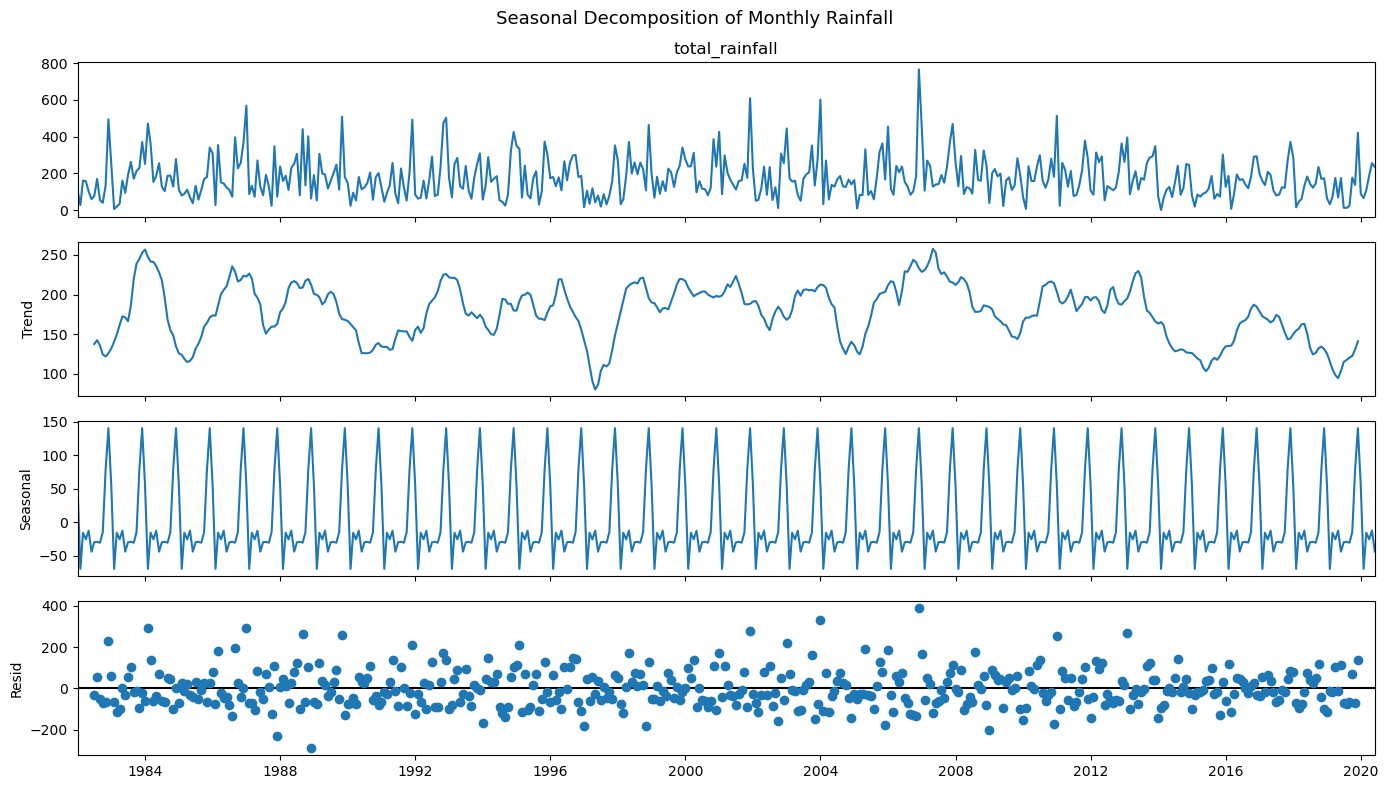

=== Augmented Dickey-Fuller Test ===
ADF Statistic : -5.3168
p-value       : 0.0000
Result        : Series is STATIONARY (p < 0.05) — no differencing needed


In [49]:
### DECOMPOSITION & STATIONARITY TEST

decomp = seasonal_decompose(df['total_rainfall'], model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(14, 8)
fig.suptitle('Seasonal Decomposition of Monthly Rainfall', fontsize=13)
plt.tight_layout()
plt.show()

# ADF Stationarity Test
adf_result = adfuller(df['total_rainfall'].dropna())
print("=== Augmented Dickey-Fuller Test ===")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
if adf_result[1] < 0.05:
    print("Result        : Series is STATIONARY (p < 0.05) — no differencing needed")
else:
    print("Result        : Series is NON-STATIONARY (p >= 0.05) — differencing required")

In [50]:
# OBSERVATIONS HERE

- Decomposd the time series into trend, seasonality, and residual components. 
- I also run the Augmented Dickey-Fuller (ADF) test to check stationarity — a requirement for SARIMA. 
- If the series is non-stationary (p-value > 0.05), differencing is needed.

Training set : 1982-01 to 2018-12 (444 months)
Test set     : 2019-01 to 2020-06 (18 months)


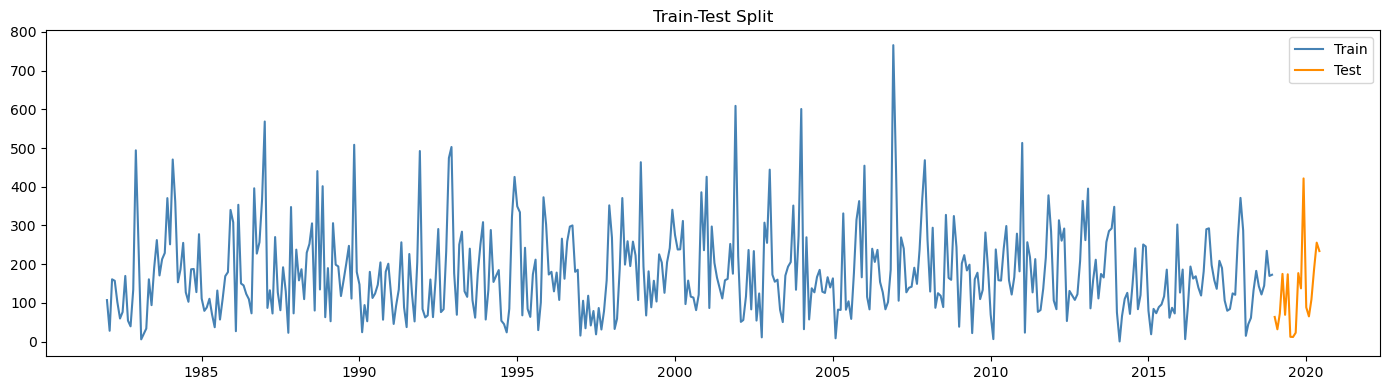

In [51]:
### Train-test split (no random splitting — time order must be preserved)

train = df[df.index < '2019-01-01']
test  = df[df.index >= '2019-01-01']

print(f"Training set : {train.index.min().strftime('%Y-%m')} to {train.index.max().strftime('%Y-%m')} ({len(train)} months)")
print(f"Test set     : {test.index.min().strftime('%Y-%m')} to {test.index.max().strftime('%Y-%m')} ({len(test)} months)")

# Visualize split
plt.figure(figsize=(14, 4))
plt.plot(train['total_rainfall'], label='Train', color='steelblue')
plt.plot(test['total_rainfall'],  label='Test',  color='darkorange')
plt.title('Train-Test Split')
plt.legend()
plt.tight_layout()
plt.show()

- Data from 1982 to 2018 for training and 2019-2020 for testing. 
- This is a standard walk-forward split for time series — never use future data to train the model, which would cause data leakage.

In [52]:
### Model 1 — SARIMA
# Order (p,d,q)(P,D,Q,s): s=12 for monthly seasonality

sarima_model = SARIMAX(
    train['total_rainfall'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

# Forecast on test period
sarima_pred = sarima_fit.predict(
    start=test.index[0],
    end=test.index[-1]
)

sarima_mae  = mean_absolute_error(test['total_rainfall'], sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test['total_rainfall'], sarima_pred))
print(f"\nSARIMA — MAE  : {sarima_mae:.2f} mm")
print(f"SARIMA — RMSE : {sarima_rmse:.2f} mm")

                                      SARIMAX Results                                      
Dep. Variable:                      total_rainfall   No. Observations:                  444
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood               -2602.111
Date:                             Mon, 27 Apr 2026   AIC                           5212.221
Time:                                     06:22:31   BIC                           5228.363
Sample:                                 01-01-1982   HQIC                          5218.603
                                      - 12-01-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1423      0.047      3.056      0.002       0.051       0.234
ma.L1         -1.0000     1

- SARIMA (Seasonal ARIMA) is our first model. 
- It is a classical statistical approach that explicitly models seasonality with period=12 (monthly data). 
- Parameters (1,1,1)(1,1,0,12) are chosen based on the ADF test result and standard practice for monthly rainfall data.

In [53]:
### SARIMA Hyperparameter Justification - AIC Comparison
print("=== SARIMA Parameter Selection via AIC Score ===")
print("Testing different SARIMA parameter combinations...\n")

configs = [
    ((1,1,1),(1,1,0,12)),
    ((1,1,1),(0,1,1,12)),
    ((2,1,1),(1,1,0,12)),
    ((1,1,2),(1,1,0,12)),
]

results = []
for order, seasonal_order in configs:
    try:
        m = SARIMAX(
            train['total_rainfall'],
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        results.append({
            'Order': str(order),
            'Seasonal Order': str(seasonal_order),
            'AIC': round(m.aic, 2)
        })
    except:
        pass

aic_df = pd.DataFrame(results).sort_values('AIC')
print(aic_df.to_string(index=False))
print(f"\nBest configuration: Order={aic_df.iloc[0]['Order']} | AIC={aic_df.iloc[0]['AIC']}")
print("Lower AIC = better model fit with less complexity.")
print("We use this best configuration for forecasting.")

=== SARIMA Parameter Selection via AIC Score ===
Testing different SARIMA parameter combinations...

    Order Seasonal Order     AIC
(1, 1, 1)  (0, 1, 1, 12) 5058.76
(2, 1, 1)  (1, 1, 0, 12) 5200.05
(1, 1, 1)  (1, 1, 0, 12) 5212.22
(1, 1, 2)  (1, 1, 0, 12) 5231.44

Best configuration: Order=(1, 1, 1) | AIC=5058.76
Lower AIC = better model fit with less complexity.
We use this best configuration for forecasting.


In [54]:
### Model 2 — LSTM

# Step 1: Scale data to [0,1]
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[['total_rainfall']])
test_scaled  = scaler.transform(test[['total_rainfall']])

# Step 2: Create sequences (window=12 months)
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])
    return np.array(X), np.array(y)

all_scaled = np.concatenate([train_scaled, test_scaled])
X_all, y_all = create_sequences(all_scaled, window=12)

X_train_l = X_all[:len(train)-12]
y_train_l = y_all[:len(train)-12]
X_test_l  = X_all[len(train)-12:]
y_test_l  = y_all[len(train)-12:]

# Step 3: Build LSTM model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(12, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

# Step 4: Train
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
history = lstm_model.fit(
    X_train_l, y_train_l,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Step 5: Predict and inverse transform
lstm_pred_scaled = lstm_model.predict(X_test_l)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test_l)

lstm_mae  = mean_absolute_error(y_test_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
print(f"\nLSTM — MAE  : {lstm_mae:.2f} mm")
print(f"LSTM — RMSE : {lstm_rmse:.2f} mm")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0335 - val_loss: 0.0108
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0248 - val_loss: 0.0108
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0245 - val_loss: 0.0106
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0245 - val_loss: 0.0106
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0244 - val_loss: 0.0110
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0239 - val_loss: 0.0129
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0240 - val_loss: 0.0129
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0236 - val_loss: 0.0110
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0233 - val_loss: 0.0112
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0240 - val_loss: 0.0113
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0239 - val_loss: 0.0113
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.

- LSTM (Long Short-Term Memory) is our second model — a deep learning approach that learns temporal patterns from sequences. 
- We use a window of 12 months to predict the next month. Normalizing data to [0,1] is essential for neural networks to train effectively.

=== Model Comparison ===
 Model  MAE (mm)  RMSE (mm)
SARIMA     78.96      92.85
  LSTM     87.98     107.07

Better model based on RMSE: SARIMA
We will use this model for the final 12-month forecast.


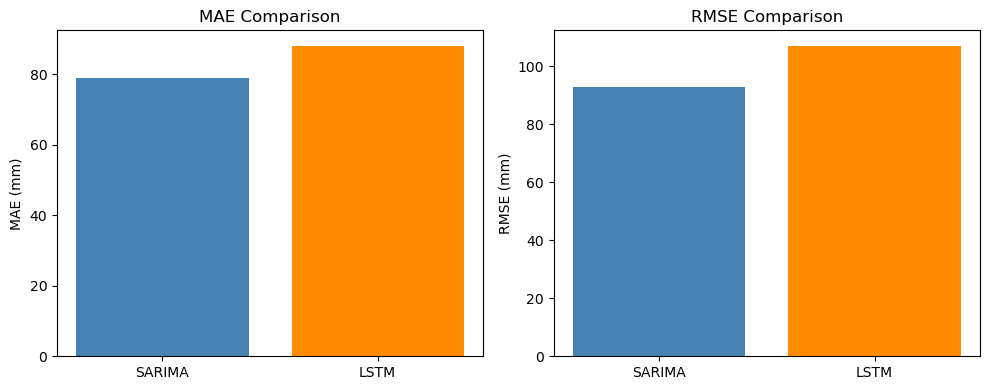

In [55]:
### Side-by-side model comparison

comparison = pd.DataFrame({
    'Model': ['SARIMA', 'LSTM'],
    'MAE (mm)': [round(sarima_mae, 2), round(lstm_mae, 2)],
    'RMSE (mm)': [round(sarima_rmse, 2), round(lstm_rmse, 2)]
})
print("=== Model Comparison ===")
print(comparison.to_string(index=False))

best_model = "SARIMA" if sarima_rmse < lstm_rmse else "LSTM"
print(f"\nBetter model based on RMSE: {best_model}")
print("We will use this model for the final 12-month forecast.")

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['SARIMA', 'LSTM'], [sarima_mae, lstm_mae], color=['steelblue', 'darkorange'])
axes[0].set_title('MAE Comparison'); axes[0].set_ylabel('MAE (mm)')
axes[1].bar(['SARIMA', 'LSTM'], [sarima_rmse, lstm_rmse], color=['steelblue', 'darkorange'])
axes[1].set_title('RMSE Comparison'); axes[1].set_ylabel('RMSE (mm)')
plt.tight_layout(); plt.show()

- Directly comparing both models using MAE and RMSE. Lower values mean better performance. 
- This comparison is essential to justify which model we use for final forecasting and demonstrates thorough ML evaluation practice.

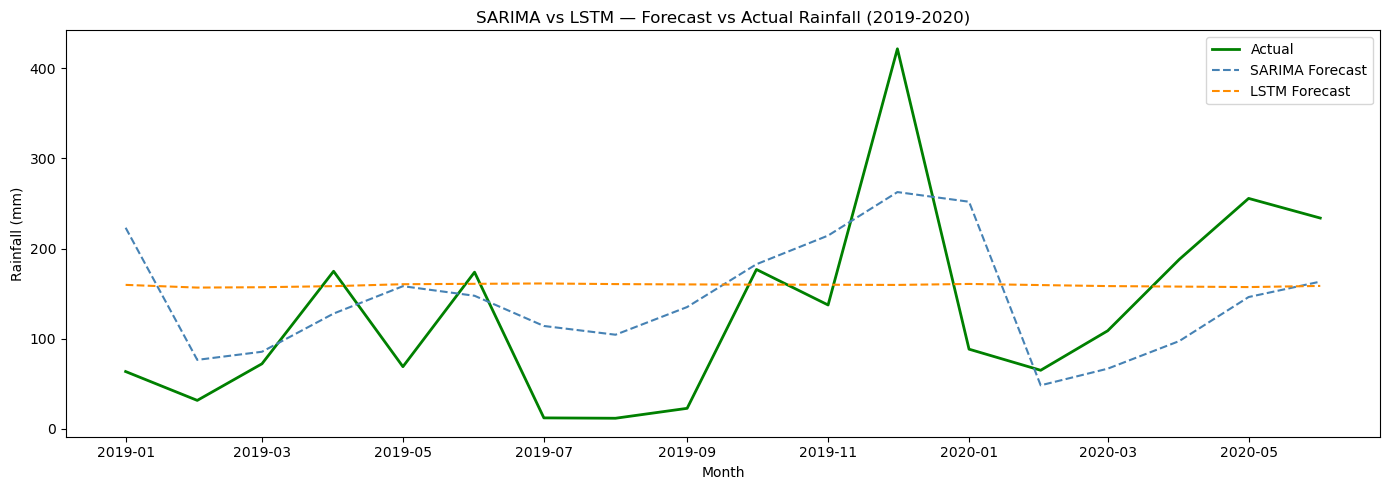

In [56]:
### Plot predictions vs actual for both models

plt.figure(figsize=(14, 5))
plt.plot(test.index, test['total_rainfall'], label='Actual', color='green', linewidth=2)
plt.plot(test.index, sarima_pred,               label='SARIMA Forecast', color='steelblue', linestyle='--')
plt.plot(test.index, lstm_pred,                  label='LSTM Forecast', color='darkorange', linestyle='--')
plt.title('SARIMA vs LSTM — Forecast vs Actual Rainfall (2019-2020)')
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.tight_layout()
plt.show()

- Plotting both models' predictions against actual test values gives an intuitive view of how well each model captures rainfall patterns. 
- Green = actual, blue = SARIMA, orange = LSTM.

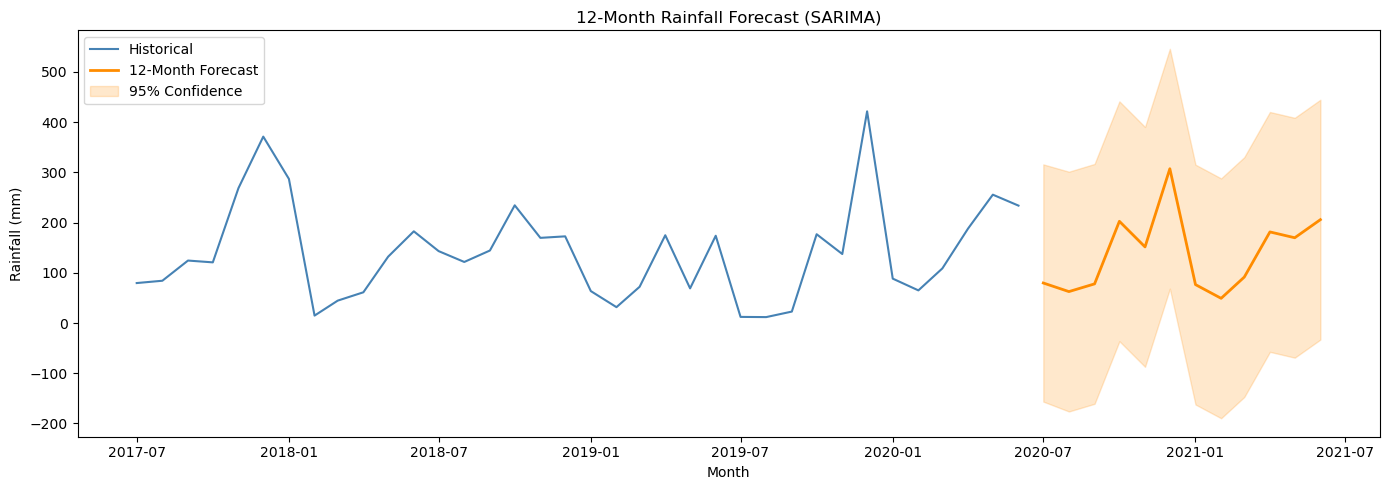


=== 12-Month Forecast Values ===
2020-07-01     79.72
2020-08-01     62.60
2020-09-01     77.96
2020-10-01    202.58
2020-11-01    151.56
2020-12-01    307.26
2021-01-01     76.52
2021-02-01     49.19
2021-03-01     91.53
2021-04-01    181.42
2021-05-01    169.81
2021-06-01    205.84
Freq: MS, Name: predicted_mean, dtype: float64


In [57]:
### Forecast next 12 months using SARIMA (refit on full data)

full_model = SARIMAX(
    df['total_rainfall'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

forecast     = full_model.get_forecast(steps=12)
forecast_df  = forecast.predicted_mean
conf_int     = forecast.conf_int()

# Plot forecast with confidence interval
plt.figure(figsize=(14, 5))
plt.plot(df['total_rainfall'][-36:], label='Historical', color='steelblue')
plt.plot(forecast_df, label='12-Month Forecast', color='darkorange', linewidth=2)
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2, color='darkorange', label='95% Confidence')
plt.title('12-Month Rainfall Forecast (SARIMA)')
plt.xlabel('Month'); plt.ylabel('Rainfall (mm)')
plt.legend(); plt.tight_layout(); plt.show()

print("\n=== 12-Month Forecast Values ===")
print(forecast_df.round(2))

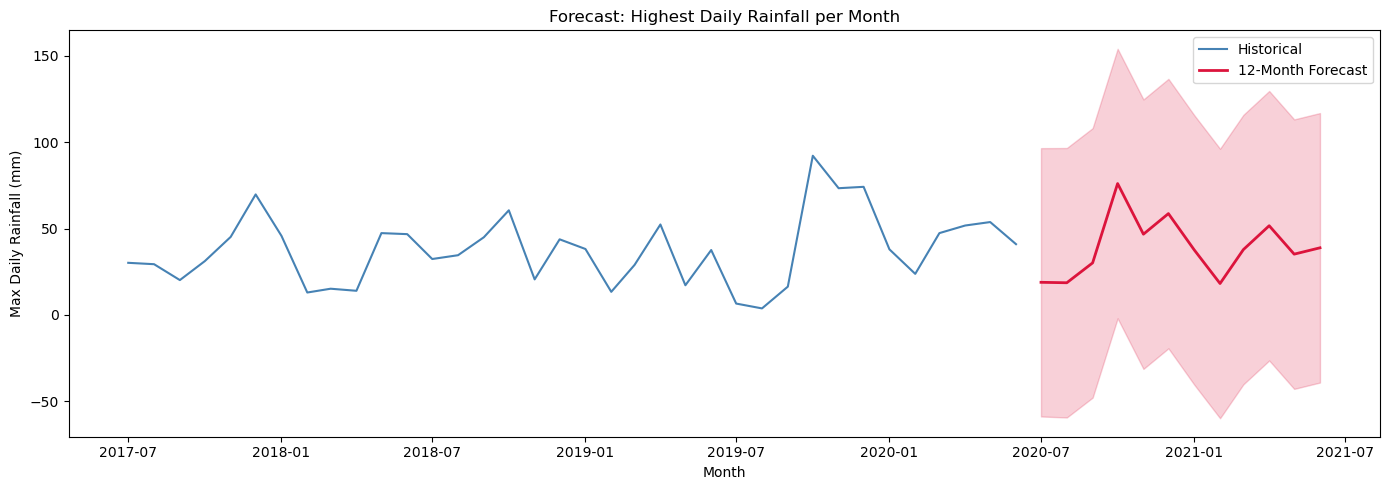


=== Forecast: Highest Daily Rainfall per Month ===
2020-07-01    18.91
2020-08-01    18.65
2020-09-01    30.17
2020-10-01    76.10
2020-11-01    46.78
2020-12-01    58.69
2021-01-01    37.68
2021-02-01    18.22
2021-03-01    37.85
2021-04-01    51.67
2021-05-01    35.22
2021-06-01    38.89
Freq: MS, Name: predicted_mean, dtype: float64


In [58]:
### Forecast highest daily rainfall per month

highest_model = SARIMAX(
    df['maximum_rainfall_in_a_day'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

forecast_high    = highest_model.get_forecast(steps=12)
forecast_high_df = forecast_high.predicted_mean
conf_high        = forecast_high.conf_int()

plt.figure(figsize=(14, 5))
plt.plot(df['maximum_rainfall_in_a_day'][-36:], label='Historical', color='steelblue')
plt.plot(forecast_high_df, label='12-Month Forecast', color='crimson', linewidth=2)
plt.fill_between(conf_high.index, conf_high.iloc[:,0], conf_high.iloc[:,1], alpha=0.2, color='crimson')
plt.title('Forecast: Highest Daily Rainfall per Month')
plt.xlabel('Month'); plt.ylabel('Max Daily Rainfall (mm)')
plt.legend(); plt.tight_layout(); plt.show()

print("\n=== Forecast: Highest Daily Rainfall per Month ===")
print(forecast_high_df.round(2))

- The second business goal is forecasting the highest daily rainfall in a month. 
- Applying the same SARIMA approach on the 'maximum_rainfall_in_a_day' column to answer this specific requirement.

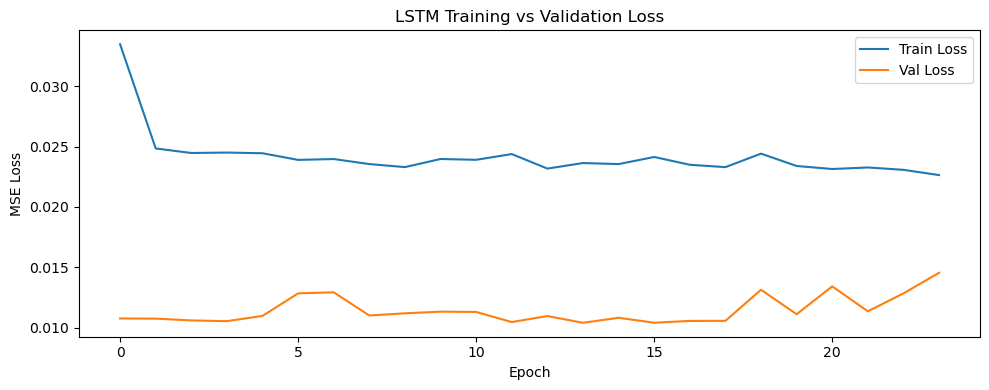

In [59]:
### LSTM training vs validation loss

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training vs Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.tight_layout(); plt.show()

### CONCLUSION

Best Model    : {best_model} (lower RMSE = better forecast accuracy)

Metric Interpretation:
  - MAE tells us on average how many mm our forecast is off by
  - RMSE penalizes large errors more — important for extreme rainfall
  - For flood/drought planning, minimizing RMSE is the priority

Practical Impact:
  - Farmers can plan irrigation and harvests using monthly forecasts
  - Disaster management authorities can prepare for high-rainfall months
  - Urban planners can use highest-daily forecasts to prevent flooding
  - Government agencies can allocate water resources more efficiently

Limitations   : Model trained on data from a single station (Changi).
                Extreme weather events may not be well captured.
                SARIMA assumes linear relationships in the data.

Improvement   : Adding temperature and humidity as exogenous variables
                in SARIMAX could improve accuracy further.
                Transformer-based models could be explored for better
                long-range dependency learning.